## Imports and Setup

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import time
import numpy as np
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

import psutil
from thop import profile
from tqdm import tqdm

In [3]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

import torch
print(f"Current PyTorch version: {torch.__version__}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
Current PyTorch version: 2.5.1


## Dataset Loader

In [4]:
test_dir = "dataset/Test"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

test_dataset = torchvision.datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

class_names = test_dataset.classes
print(class_names)

['anger', 'fear', 'happy', 'neutral', 'sad']


## Load Models

In [5]:
from torchvision.models import resnet18, mobilenet_v3_large, efficientnet_v2_s

models = {}

# ResNet18
resnet = resnet18(num_classes=5)
resnet.load_state_dict(torch.load("models/new_train/ResNet18.pt"))
resnet.to(device).eval()
models["ResNet18"] = resnet

# MobileNetV3
mobilenet = mobilenet_v3_large(num_classes=5)
mobilenet.load_state_dict(torch.load("models/new_train/MobileNetV2.pt"))
mobilenet.to(device).eval()
models["MobileNet"] = mobilenet

# EfficientNetV2
efficientnet = efficientnet_v2_s(num_classes=5)
efficientnet.load_state_dict(torch.load("models/new_train/EfficientNetV2.pt"))
efficientnet.to(device).eval()
models["EfficientNetV2"] = efficientnet

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2956\2132687325.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load("models/new_train/ResNet18

## Accuracy Benchmark

In [6]:
def evaluate_model(model):

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in tqdm(test_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    return acc, precision, recall, f1, y_true, y_pred

results = {}

for name, model in models.items():

    print(f"Evaluating {name}")

    acc, precision, recall, f1, y_true, y_pred = evaluate_model(model)

    results[name] = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    print(classification_report(y_true, y_pred))

Evaluating ResNet18


100%|██████████| 196/196 [00:15<00:00, 12.29it/s]


              precision    recall  f1-score   support

           0       0.82      0.53      0.64      1253
           1       0.78      0.73      0.75      1253
           2       0.93      0.89      0.91      1253
           3       0.87      0.90      0.88      1253
           4       0.58      0.82      0.68      1253

    accuracy                           0.77      6265
   macro avg       0.79      0.77      0.77      6265
weighted avg       0.79      0.77      0.77      6265

Evaluating MobileNet


100%|██████████| 196/196 [00:15<00:00, 12.81it/s]


              precision    recall  f1-score   support

           0       0.24      0.56      0.34      1253
           1       0.32      0.54      0.40      1253
           2       0.95      0.17      0.29      1253
           3       0.41      0.26      0.32      1253
           4       0.56      0.11      0.18      1253

    accuracy                           0.33      6265
   macro avg       0.50      0.33      0.31      6265
weighted avg       0.50      0.33      0.31      6265

Evaluating EfficientNetV2


100%|██████████| 196/196 [00:18<00:00, 10.66it/s]

              precision    recall  f1-score   support

           0       0.71      0.87      0.78      1253
           1       0.83      0.80      0.81      1253
           2       0.95      0.94      0.94      1253
           3       0.94      0.95      0.94      1253
           4       0.82      0.67      0.73      1253

    accuracy                           0.84      6265
   macro avg       0.85      0.84      0.84      6265
weighted avg       0.85      0.84      0.84      6265



## Confusion Matrix Visualization

In [7]:
def plot_confusion_matrix(y_true, y_pred, model_name):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

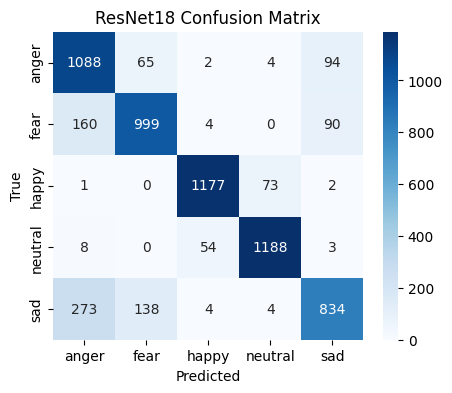

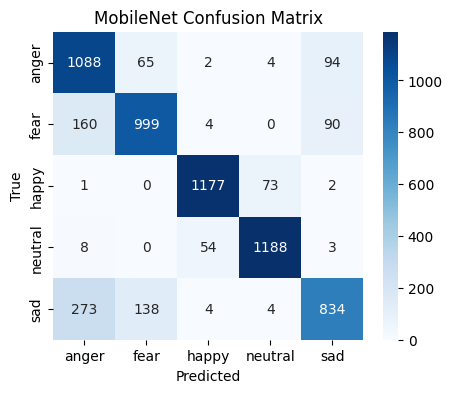

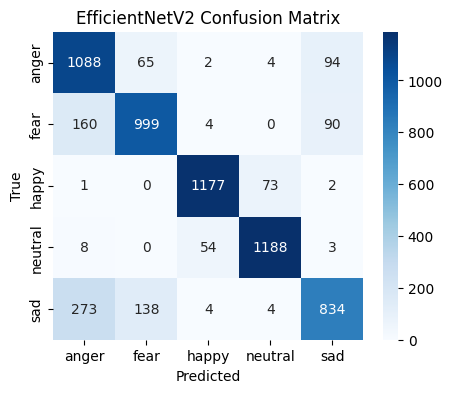

In [8]:
plot_confusion_matrix(y_true, y_pred, "ResNet18")
plot_confusion_matrix(y_true, y_pred, "MobileNet")
plot_confusion_matrix(y_true, y_pred, "EfficientNetV2")

## Inference Speed Benchmark

In [9]:
def benchmark_speed(model):

    model.eval()

    dummy = torch.randn(1,3,224,224).to(device)

    # warmup
    for _ in range(20):
        _ = model(dummy)

    torch.cuda.synchronize()

    start = time.time()

    iterations = 200

    for _ in range(iterations):
        _ = model(dummy)

    torch.cuda.synchronize()

    end = time.time()

    latency = (end-start)/iterations
    throughput = 1/latency

    return latency*1000, throughput

for name, model in models.items():

    latency, throughput = benchmark_speed(model)

    results[name]["latency_ms"] = latency
    results[name]["throughput"] = throughput

## Model Complexity

In [10]:
def model_complexity(model):

    dummy = torch.randn(1,3,224,224).to(device)

    flops, params = profile(model, inputs=(dummy,), verbose=False)

    params = params / 1e6
    flops = flops / 1e9

    return params, flops

for name, model in models.items():

    params, flops = model_complexity(model)

    results[name]["params_M"] = params
    results[name]["flops_G"] = flops

## GPU / RAM Usage

In [11]:
def hardware_usage(model):

    torch.cuda.reset_peak_memory_stats()

    dummy = torch.randn(32,3,224,224).to(device)

    _ = model(dummy)

    gpu_mem = torch.cuda.max_memory_allocated() / (1024**2)

    ram = psutil.virtual_memory().used / (1024**3)

    return gpu_mem, ram

for name, model in models.items():

    gpu, ram = hardware_usage(model)

    results[name]["gpu_MB"] = gpu
    results[name]["ram_GB"] = ram

## Final Benchmark Table

In [17]:
df = pd.DataFrame(results).T

# styled = df.style \
# .highlight_max(subset=["accuracy", "precision", "recall", "f1"], color="green") \
# .highlight_min(subset=["latency_ms", "throughput", "params_M", "flops_G"], color="blue") \
# .highlight_max(subset=["gpu_MB", "ram_GB"], color="lightred") \
# .format(precision=4)

display(df.style)

,accuracy,precision,recall,f1,latency_ms,throughput,params_M,flops_G,gpu_MB,ram_GB
ResNet18,0.774940,0.794077,0.774940,0.774258,2.234758,447.475717,11.179077,1.823524,836.183594,14.338501
MobileNet,0.327215,0.497248,0.327215,0.305425,6.160810,162.316319,4.208437,0.233565,1513.254883,14.338440
EfficientNetV2,0.843735,0.848415,0.843735,0.842916,18.988292,52.664030,20.183893,2.900662,4867.009766,14.356045


## Accuracy vs Model Size trade off

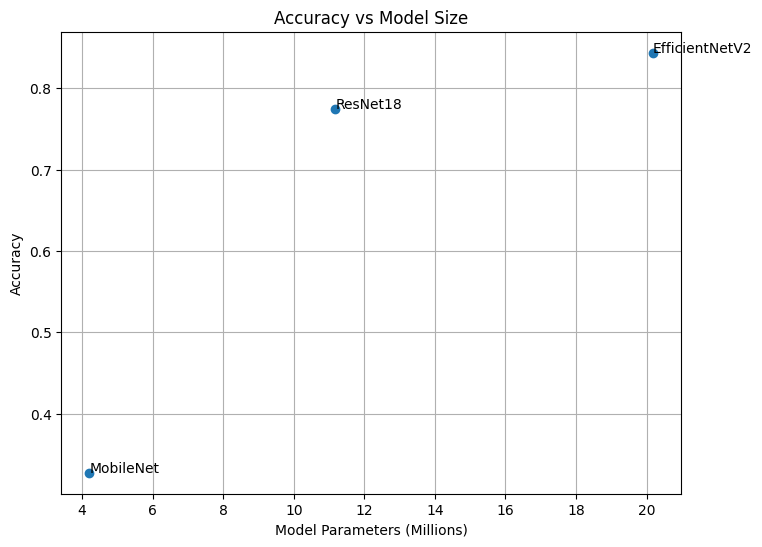

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(df["params_M"], df["accuracy"])

for model in df.index:
    plt.text(df.loc[model,"params_M"],
             df.loc[model,"accuracy"],
             model)

plt.xlabel("Model Parameters (Millions)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Model Size")

plt.grid(True)
plt.show()

Models with more parameters generally achieve higher accuracy but require more computational resources.

## Speed vs Accuracy Trade-off

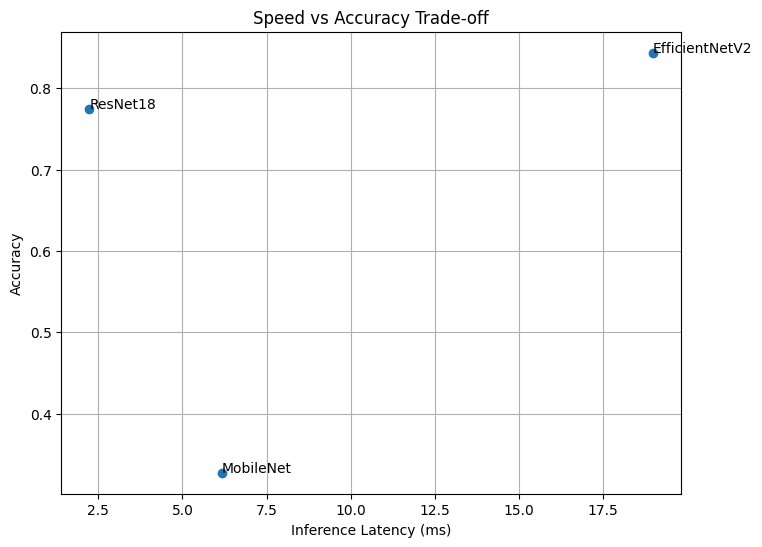

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(df["latency_ms"], df["accuracy"])

for model in df.index:
    plt.text(df.loc[model,"latency_ms"],
             df.loc[model,"accuracy"],
             model)

plt.xlabel("Inference Latency (ms)")
plt.ylabel("Accuracy")
plt.title("Speed vs Accuracy Trade-off")

plt.grid(True)
plt.show()

Interpretation:
- top-left = best models
- bottom-right = slow and inaccurate

Typically:
- MobileNet → fastest
- EfficientNet → highest accuracy